
# <h1 style='color:#1B3A6B;'>1. NOMBRE DEL PROYECTO </h1>

## <span style ='color:#2E86AB;'>OilyGiant: ANÁLISIS DE RIESGO Y SELECCIÓN DE REGIONES PETROLERAS </span>
---


---
# <span style='color:#1B3A6B ;'> 2. OBJETIVO </span>
---

## <span style='color:#2E86AB;'> 2.1. General </span>

* Identificar la región optima para abrir 200 nuevos pozos petroleros maximizando el beneficio y minimizando el riesgo de pérdida.

## <span style='color:#2E86AB;'> 2.2 Específico </span>

* Construir un modelo predictivo del volumen de reservas por pozo.
* Seleccionar los 200 pozos con mayor potencial estimado.
* Elegir la región con el mayor beneficio total mediante el análisis de riesgo con 'Bootstrapping'.

---
# <span style='color:#1B3A6B;'> 3. DESCRIPCIÓN </span> 
---

## <span style='color:#2E86AB;'> 3.1. Condiciones del Negocio </span>

| Parámetros | Valor |
|------------|-------|
| Puntos explorados por región | 500 |
| Pozos a desarrollar | 200 |
| Presupuesto total | ``` $ 100,000,000 USD ``` |
| Ingreso por barril |``` $ 4.5 USD ```|
| Ingreso por unidad (miles de barriles) | ```$ 4,500 USD``` |
| Umbral de riesgo | <2.5% |
| Modelo permitido | Solo Regresión Lineal |


## <span style='color:#2E86AB;'> 3.2. Descripción de Datos </span>

Tres archivos CSV con datos de exploración geológica de las 3 regiones: 

* `geo_data_0.csv` : Región 0
* `geo_data_1.csv` : Región 1
* `geo_data_2.csv` : Región 2

**Columnas:**

* `id`         : Identificador único del pozo
* `f0, f1, f2` : Característica del punto
* `product`    : Volumen de reservas (miles de barriles) → **Variable Objetivo**



---
# <span style='color:#1B3A6B;'> 4. PREPARACIÓN DE DATOS </span>
---

## <span style='color:#1B3A6B;'> 4.1. Importación de Librerías </span>

In [1]:
import pandas as pd                         # Maneja y manipula datos en tablas
import numpy as np                          # Realiza operaciones matemáticas complejas y vectoriales
import matplotlib.pyplot as plt             # Librería para gráficas
import seaborn as sns                       # Librería para gráficas más estéticas

from sklearn.linear_model import LinearRegression           # Modelo de regresión lineal
from sklearn.model_selection import train_test_split        # Divide conjunto de datos en train-valid-test
from sklearn.model_selection import cross_val_score, KFold  # Validación cruzada
from sklearn.metrics import mean_squared_error              # Mide qué tan bien predice el modelo de los valores reales: 0.0 perfecto, valores elevados predice mal

from scipy import stats                                     # Herramientas estadísticas (intervalos de confianza etc)

import warnings
warnings.filterwarnings('ignore')                           # Maneja advertencias de python

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')                     # Estilo visual de gráficas
pd.set_option('display.float_format', '{:.2f}'.format)      # Mostrar decimales redondeados a 2

RANDOM_STATE = 42                                           # Número de aleatoria 

## <span style='color:#2E86AB;'> 4.2. Cargar los Datasets </span>

In [2]:
df0_orig = pd.read_csv("/Users/Loarte Juan/Documents/Dataset_Project_12/geo_data_0.csv")
df1_orig = pd.read_csv("/Users/Loarte Juan/Documents/Dataset_Project_12/geo_data_1.csv")
df2_orig = pd.read_csv("/Users/Loarte Juan/Documents/Dataset_Project_12/geo_data_2.csv")

df0 = df0_orig.copy()
df1 = df1_orig.copy()
df2 = df2_orig.copy()

datasets = {'Región 0' : df0,
            'Región 1' : df1,
            'Región 2' : df2}

print('Datasets cargados correctamente')

Datasets cargados correctamente


## <span style='color:#2E86AB;'> 4.3. Exploración inicial de Datos </span>

In [3]:
# Exploración EDA

for nombre, df in datasets.items():
    print(f'\n=================== {nombre} ========================')
    
    print(f'\n================ PRIMERA 5 FILAS ====================')
    print(df.head())
    
    print(f'\n========== INFORMACIÓN GENERAL DEL DATASET ==========')
    print(df.info())
    
    print(f'\n============= DESCRIPCIÓN DEL DATASET ===============')
    print(df.describe())

    print(f'\n================ FILAS Y COLUMNAS ===================')
    print(f" Filas   : {df.shape[0]}")
    print(f"Columnas : {df.shape[1]}")

    print(f"\n================= TIPO DE DATOS =====================")
    print(df.dtypes)


=================== Región 0 ========================

================ PRIMERA 5 FILAS ====================
      id    f0    f1   f2  product
0  txEyH  0.71 -0.50 1.22   105.28
1  2acmU  1.33 -0.34 4.37    73.04
2  409Wp  1.02  0.15 1.42    85.27
3  iJLyR -0.03  0.14 2.98   168.62
4  Xdl7t  1.99  0.16 4.75   154.04

========== INFORMACIÓN GENERAL DEL DATASET ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None

============= DESCRIPCIÓN DEL DATASET ===============
             f0        f1        f2   product
count 100000.00 100000.00 100000.00 100000.00
mean       0.50      0.25      2.50    

## <span style='color:#2E86AB;'>4.4. Verificar Valores Ausentes y Duplicados </span>

In [4]:
# Valores Ausentes y duplicados

for nombre, df in datasets.items():
    print(f"\n--------------- {nombre} ----------------")
    print("============== NULOS POR COLUMNA============")
    print(df.isnull().sum())
    
    print(f"\n==============DUPLICADOS=================")
    print(f" Valores duplicados: {df.duplicated().sum()}")


--------------- Región 0 ----------------
============== NULOS POR COLUMNA============
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

==============DUPLICADOS=================
 Valores duplicados: 0

--------------- Región 1 ----------------
============== NULOS POR COLUMNA============
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

==============DUPLICADOS=================
 Valores duplicados: 0

--------------- Región 2 ----------------
============== NULOS POR COLUMNA============
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

==============DUPLICADOS=================
 Valores duplicados: 0


---
> **OBSERVACIONES DURANTE LA EXPLORACIÓN EDA**
---
* Durante la exploración 'EDA' se identifica en los `3 Datasets` de cada región 100000 filas y 5 columnas cada uno con las siguientes observaciones:

1. `Valores ausentes:`   0 en los tres datasets. No se requiere imputación.
2. `Valores duplicados:` 0 en los tres datasets.
3. `Tipo de datos:` las 5 columnas cuenta con tipo de dato adecuado al contenido en la celdas:

| COLUMNA | TIPO DE DATOS | 
|---------|---------------|
|   id    |    object     | 
|   f0    |    float64    |               
|   f1    |    float64    |
|   f2    |    float64    |
| product |    float64    |

4. En la variable objetivo `product` existen diferencias notables entre regiones:

* Región 0: media = 92.50, mín = 0.00, máx = 185.36
* Región 1: media = 68.83, mín = 0.00, máx = 137.95  -> **La más baja**
* Región 2: media = 95.00, mín = 0.00, máx = 190.03  -> **La más alta**

Por lo tanto, la región con mayor volumen de reserva es la región 2 (mean 95.00), seguida de la región 0 y con menos volumen la región 1 (mean 68.83).

5. Características `f0, f1, f2`:

| Variable | Región 0 | Región 1 | Región 2 |
|----------|----------|----------|----------|
| f0 | -1.41 → 2.36 | -31.61 → 29.42 | -8.76 → 7.24 |
| f1 | -0.85 → 1.34 | -26.36 → 18.73 | -7.08 → 7.84 |
| f2 | -12.09 → 16.00 | -0.02 → 5.02 | -11.97 → 16.74 |

* En las regiones 0 y 2 los rangos de `f0` y `f1`  son moderados, mientras que en la Región 1 presenta rangos más amplios: `f0` va de -31.61 a 29.42 y `f1` de -26.36 a 18.73. Esto implica mayor dispersión o variabilidad geológica en esa región, por lo tanto requiere mayor atención al momento de escalar o normalizar las features.

* Particularidad de `f2` en la `Región 1`: `f2` se mueve en un rango muy estrecho en valores discretos como 0,1,2,3,4 y 5; esto sugiere que `f2` en la región 1 podría comportarse más como una variable categórica o con precisión limitada, lo cuál es relevante para el modelo.

* `id:` se descarta como feature, es solo una etiqueta, no aporta poder predictivo.

* Las tres regiones comparten la misma estructura de datos y ausencia de nulos, lo que facilita aplicar el mismo pipeline de modelado.

---
# <span style='color:#1B3A6B;'> 5. ENTRENAMIENTO Y EVALUACIÓN DEL MODELO </span>
---
## <span style='color:#2E86AB;'> 5.1. Definición de Funciones del Pipeline </span>

> 

In [5]:
# Entrenar modelo de regresión lineal con validación cruzada K-Fold y evalúa el desempeño
# Retorna: predicciones (array), respuestas reales (Series), 
#          rmse_cv (float), rmse_std(float,) media_predicha (float)

def entrenar_evaluar_modelo(df, nombre_region, n_splits= 5, random_state=42):
    # Separar features y target
    features = df[['f0', 'f1', 'f2']]
    target   = df['product']

    # Validación cruzada K-Fold
    modelo = LinearRegression()
    kf     = KFold(n_splits= n_splits, shuffle= True, random_state= random_state )               # 5 folds reproducibles

    rmse_folds = -cross_val_score(modelo, features, target,                                      # Cross_val_score devuelve valores negativos
                                  cv      =kf,
                                  scoring = 'neg_root_mean_squared_error')                       # Convertir a positivos con el signo negativo
    
    rmse_cv  = rmse_folds.mean()                                                                 # RMSE promedio de los 5 folds
    rmse_std = rmse_folds.std()                                                                  # Desviación estándar, que tan estable es RMSE entre folds
    
   
    
    # División de datos train/valid para bootstrapping
    train_features, valid_features, train_target, valid_target = train_test_split(features, 
                                                                                  target,
                                                                                  test_size    = 0.25,
                                                                                  random_state = random_state)  

    # Entrenamiento 
    modelo.fit(train_features, train_target)

    # Predicciones
    predicciones = modelo.predict(valid_features)                                                 # Array de predicciones sobre validación

    # Métricas
    media_predicha = predicciones.mean()

    print(f"\n ======================={nombre_region}============================")
    print(f"RMSE por fold (CV)    : {[f'{r:.2f}' for r in rmse_folds]}")
    print(f"RMSE medio (CV)       : {rmse_cv:.2f}")   
    print(f"Desviación std (CV)   : {rmse_std:.2f}       <- mientras más bajo, más estable")     
    print(f"Volumen medio predicho: {media_predicha:.2f} miles de barriles")
    

    return predicciones, valid_target, rmse_cv, rmse_std, media_predicha


## <span style='color:#2E86AB;'> 5.2. Región 0 (geo_data_0.csv)

### <span style="color:#2E86AB;"> 5.2.1 - 5.2.4 Entrenamiento, Predicciones y Métricas 

In [21]:
pred_0, real_0, rmse_0, rmse_std_0, media_0 = entrenar_evaluar_modelo(df0, 'Región 0', random_state= RANDOM_STATE)


 =======================Región 0============================
RMSE por fold (CV)    : ['37.65', '37.50', '37.70', '37.93', '37.68']
RMSE medio (CV)       : 37.69
Desviación std (CV)   : 0.14       <- mientras más bajo, más estable
Volumen medio predicho: 92.40 miles de barriles


## <span style='color: #2E86AB;'> 5.3. Región 1 (geo_data_1.csv)

### <span style='color: #2E86AB;'> 5.3.1 - 5.3.4 Entrenamiento, Predicciones y Métricas

In [28]:
pred_1, real_1, rmse_1, rmse_std_1, media_1 = entrenar_evaluar_modelo(df1, 'Región 1', random_state=RANDOM_STATE)


 =======================Región 1============================
RMSE por fold (CV)    : ['0.89', '0.89', '0.89', '0.90', '0.89']
RMSE medio (CV)       : 0.89
Desviación std (CV)   : 0.00       <- mientras más bajo, más estable
Volumen medio predicho: 68.71 miles de barriles


## <span style='color:#2E86AB;'> 5.4. Región 2 (geo_data_2.csv) </span>

### <span style='color:#2E86AB;'> 5.4.1 - 5.4.4 Entrenamiento, Predicciones y Métricas </span>

In [29]:
pred_2, real_2, rmse_2, rmse_std_2, media_2 = entrenar_evaluar_modelo(df2, 'Región 2', random_state=RANDOM_STATE)


 =======================Región 2============================
RMSE por fold (CV)    : ['40.16', '40.03', '40.12', '40.06', '39.92']
RMSE medio (CV)       : 40.06
Desviación std (CV)   : 0.08       <- mientras más bajo, más estable
Volumen medio predicho: 94.77 miles de barriles


## <span style ='color:#2E86AB;'> 5.5. Comparativa General entre Regiones y Gráfica de Dispersión</span>

In [32]:
rmse_0_relativa = (rmse_0 / media_0) * 100
rmse_1_relativa = (rmse_1 / media_1) * 100
rmse_2_relativa = (rmse_2 / media_2) * 100

comparativa = pd.DataFrame({
    'Región'                 : ['Región 0', 'Región 1', 'Región 2'],
    'Volumen Medio Predicho' : [media_0,    media_1,    media_2],
    'RMSE CV (medio)'        : [rmse_0,     rmse_1,     rmse_2],
    'RMSE Std (estabilidad)' : [rmse_std_0, rmse_std_1, rmse_std_2],
    'RMSE Relativo %'        : [rmse_0_relativa, rmse_1_relativa, rmse_2_relativa]
})

print(comparativa)


     Región  Volumen Medio Predicho  RMSE CV (medio)  RMSE Std (estabilidad)  \
0  Región 0                   92.40            37.69                    0.14   
1  Región 1                   68.71             0.89                    0.00   
2  Región 2                   94.77            40.06                    0.08   

   RMSE Relativo %  
0            40.79  
1             1.30  
2            42.27  


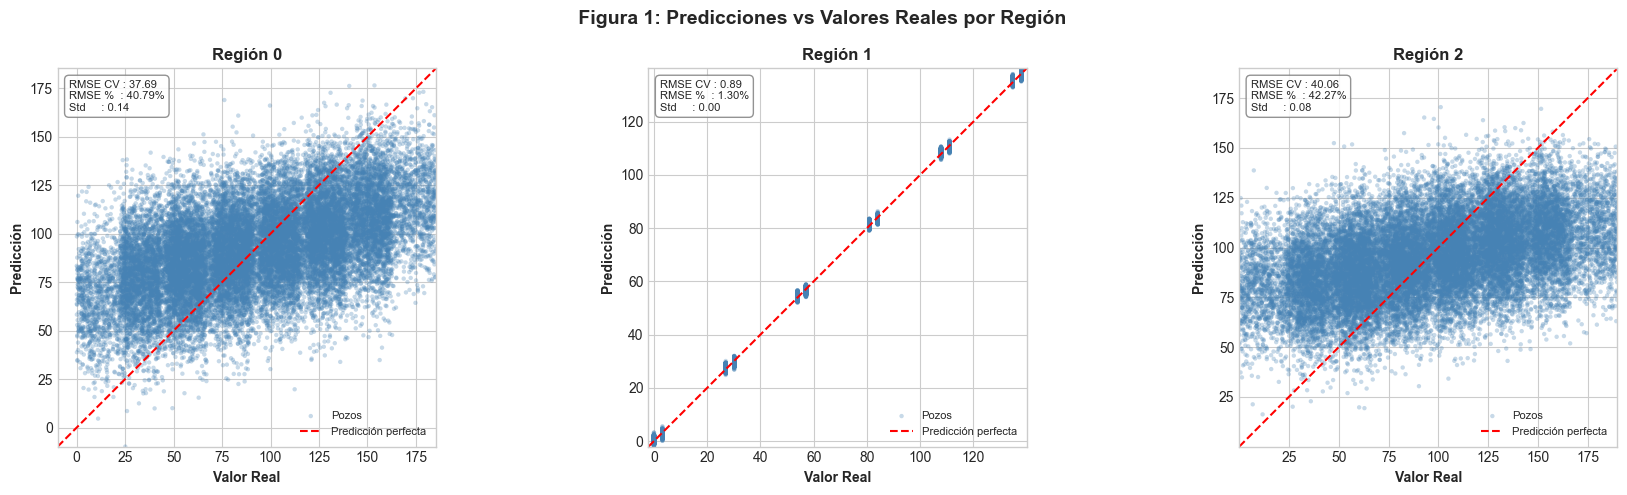

In [39]:
# Gráfico de dispersión: Predicciones vs Valores Reales por región

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datos = [
    ('Región 0', real_0, pred_0),
    ('Región 1', real_1, pred_1),
    ('Región 2', real_2, pred_2),
]

for ax, (nombre, real, pred) in zip(axes, datos):
    
    # Límites compartidos para ejes x e y
    lim_min = min(real.min(), pred.min())
    lim_max = max(real.max(), pred.max())

    # Scatter: predicciones vs valores reales
    ax.scatter(real, pred,
               alpha     = 0.3,
               s         = 10,
               color     = 'steelblue',
               edgecolor = 'none',
               label     = 'Pozos')

    # Línea diagonal perfecta (predicción ideal)
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            color     = 'red',
            linewidth = 1.5,
            linestyle = '--',
            label     = 'Predicción perfecta')

    # Anotación con RMSE y RMSE%
    rmse_rel = (rmse_0 if nombre == 'Región 0' else
                rmse_1 if nombre == 'Región 1' else rmse_2)
    media    = (media_0 if nombre == 'Región 0' else
                media_1 if nombre == 'Región 1' else media_2)
    std      = (rmse_std_0 if nombre == 'Región 0' else
                rmse_std_1 if nombre == 'Región 1' else rmse_std_2)

    texto = (
        f"RMSE CV : {rmse_rel:.2f}\n"
        f"RMSE %  : {(rmse_rel/media)*100:.2f}%\n"
        f"Std     : {std:.2f}"
    )
    ax.text(0.03, 0.97, texto,
            transform           = ax.transAxes,
            fontsize            = 8,
            verticalalignment   = 'top',
            horizontalalignment = 'left',
            bbox = dict(boxstyle='round,pad=0.4',
                        facecolor='white', alpha=0.85, edgecolor='gray'))

    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    ax.set_title(nombre,        fontweight='bold')
    ax.set_xlabel('Valor Real', fontweight='bold')
    ax.set_ylabel('Predicción', fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_aspect('equal')                          # Ejes con la misma escala

plt.suptitle(' Figura 1: Predicciones vs Valores Reales por Región',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **OBSERVACIONES ENTRENAMIENTO Y EVALUACIÓN DEL MODELO**
> Validación Cruzada K-Fold

|Región | Volumen Medio Predicho | RMSE CV (medio) | RMSE Std | RMSE Relativo % |
|-------|------------------------|-----------------|----------|-----------------|
| Región 0 | 92.40 | 37.69 | 0.14 | 40.79 % |
| **Región 1** | **68.71** | **0.89** | **0.00** | **1.30 %** |  
| Región 2 | 94.77 | 40.06 | 0.08 | 42.27 % |

El **RMSE= 0.89** de **Región 1** con una única participación, podría ser el resultado de una división afortunada de los datos. **K-Fold (K =5)**, divide el dataset en 5 conjuntos distintos y el modelo evalúa 5 veces. Si el resultado de RMSE medio y su desviación estándar son bajos y consistentes, confirma que el resultado es robusto y no dependiente del random_state.    

* **Región 0:** El modelo predice un volumen medio de 92.40 miles de barriles muy cercano a la media real observada en el EDA (92.50), esto indica que el modelo captura bien el nivel central de la distribución. Sin embargo el RMSE de 37.69 es elevado en relación al rango de la variable objetivo (0-185), lo que sugiere que las predicciones individuales presentan errores considerables y el modelo tiene dificultades para capturar la variabilidad de los datos. 
  
* **Región 1:** Es el resultado más destacado de los 3. El modelo obtiene un **RMSE CV medio de 0.89** consistente en los 5 folds (['0.89', '0.89', '0.89', '0.90', '0.89']), con una **desviación estándar de 0.00**, lo que confirma que las predicciones se ajustan casi perfectamente a los valores reales sin importar cómo se dividan los datos.
Este resultado no es producto de una partición afortunada, es estadísticamente robusto. La causa se identificó desde el EDA: f2 en la **Región 1** toma valores casi discretos concentrados entre 0 y 5, lo que establece una relación lineal directa y predecible con product que la regresión lineal captura perfectamente. Una std de 0.00 relativa a un RMSE de 0.89 indica que el modelo aprendió un patrón real y estable en los datos; no hay ruido,  algo que los modelos inestables no pueden garantizar.

  
* **Región 2:** Es similar a la Región 0, se observa un volumen medio predicho de 94.77 aproximándose bien la media real encontrada en el EDA (95.00), su RMSE es de 40.06 (elevado) lo que indica que, a pesar de acertar en el promedio, el modelo comete errores individuales aquí. La mayor dispersión de `f0` y `f1` en esta región (std de 1.73 frente a 0.87 en Región 0) puede estar contribuyendo a este comportamiento.

---
> **OBSERVACIONES - Gráfico de Dispersión: Predicciones vs Valores Reales**

En la gráfico 1 confirma visualmente lo que las métricas ya indicaban:

* `Región 0 y Región 2` presentan una nube de puntos ampliamente dispersa alrededor de la línea de predicción perfecta (roja discontinua). Los puntos se alejan considerablemente de la diagonal en ambas direcciones, lo que confirma que el modelo acierta el promedio general pero comete errores importantes a nivel individual, consistente con un RMSE relativo del 40.79% y 42.27% respectivamente.

* La `Región 1` muestra un comportamiento completamente distinto: los puntos se agrupan en bandas verticales casi perfectamente sobre la línea diagonal, formando un patrón de escalera. Esto es la representación visual del comportamiento casi discreto de **f2** identificado en el **EDA**, cada banda corresponde a un valor entero de **f2 (0, 1, 2, 3, 4, 5)** y el modelo predice cada grupo con una precisión casi exacta. Esto explica de forma visual por qué el `RMSE es de 0.89 con std de 0.00.`
---

> **Conclusión General:** 

* Los tres modelos logran estimar correctamente el volumen medio, pero solo la **Región 1** lo hace con precisión a nivel individual. Su **RMSE_CV de 0.89** se mantiene consistente a lo largo de los 5 folds con una desviación estándar de 0.00, confirmando que su precisión no es un artefacto estadístico sino un patrón real aprendido por el modelo. Con un error de apenas **1.30%** del volumen medio predicho, es el modelo más preciso con diferencia frente a las Regiones 0 y 2, que superan el 40%. Este resultado hace más confiable la selección de pozos y, por ende, el análisis de ganancias y bootstrapping en los pasos siguientes.

* Las Regiones 0 y 2 presentan un RMSE CV de 37.69 y 40.06 respectivamente, representando el 40.79% y 42.27% del volumen medio predicho. Esto confirma que, aunque los modelos aciertan en el promedio general, las predicciones individuales son poco confiables. Sus desviaciones estándar (0.14 y 0.08) son bajas y consistentes entre folds, lo que indica que el modelo aprende de forma estable pero aprende mal; el error es alto, pero siempre alto de la misma manera. Esto introduce mayor incertidumbre en la selección puntual de pozos, razón por la cual el bootstrapping del paso 8 es determinante para evaluar si esa imprecisión afecta la rentabilidad final.

* Por esta razón, la decisión final no puede basarse únicamente en el RMSE, sino que requiere el análisis de Bootstrapping para comparar las ganancias esperadas y el riesgo real entre regiones.


---
# <span style='color:#1B3A6B;'> 6. PREPARACIÓN PARA EL CÁLCULO DE GANANCIAS </span>
---
## <span style='color:#2E86AB; '> 6.1. Definición de Variables y Constantes del Negocio </span>

In [10]:
# Definición de variables
PRESUPUESTO        = 100_000_000       # USD
INGRESO_POR_UNIDAD = 4_500             # USD por miles (1000) de barriles
N_POZOS            = 200               # Pozos a desarrollar
N_PUNTOS           = 500               # Puntos explorados por región
N_BOOTSTRAP        = 1000              # Muestras para bootstrapping
UMBRAL_RIESGO      = 0.025             # 2.5%

COSTO_POR_POZO = PRESUPUESTO / N_POZOS
print(f"Costo promedio por pozo es: ${COSTO_POR_POZO:,.0f} USD")

Costo promedio por pozo es: $500,000 USD


## <span style='color:#2E86AB;'> 6.2. Volumen Mínimo Requerido por Pozo para No Incurrir en Pérdidas </span>

In [11]:
volumen_minimo = COSTO_POR_POZO / INGRESO_POR_UNIDAD
print(f"Volumen mínimo por pozo para cubrir costos: {volumen_minimo:.2f} miles de barriles")

Volumen mínimo por pozo para cubrir costos: 111.11 miles de barriles


## <span style='color:#2E86AB;'>6.3. Comparación del Umbral Mínimo con las Reservas Promedio por Región </span>

In [12]:
# Comparación del Umbral mínimo

for nombre, media in zip(['Región 0', 'Región 1', 'Región 2'], [media_0, media_1, media_2]):       # Itera y une sobre cada región y su media predicha al mismo tiempo
    diferencia = media - volumen_minimo                                                            # Calcula cuánto supera (o falta) respecto al umbral mínimo
    estado     = '✅ Supera el Umbral' if diferencia >= 0 else '⚠️Por debajo del umbral'          # Asigna una etiqueta según si cumple o no el umbral
    print(f'{nombre}: media={media:.2f} | mínimo= {volumen_minimo:.2f} | diferencia= {diferencia:.2f} -> {estado}') 


Región 0: media=92.40 | mínimo= 111.11 | diferencia= -18.71 -> ⚠️Por debajo del umbral
Región 1: media=68.71 | mínimo= 111.11 | diferencia= -42.40 -> ⚠️Por debajo del umbral
Región 2: media=94.77 | mínimo= 111.11 | diferencia= -16.34 -> ⚠️Por debajo del umbral


> **OBSERVACIONES DEL CÁLCULO DE GANANCIAS Y UMBRAL DE RENTABILIDAD:**

El umbral de rentabilidad se determinó a partir de parámetros del negocio: **presupuesto** ```$100,000,000 USD``` distribuido entre 200 pozos, el costo por pozo es de `$500,000 USD`. Dado que cada millar de barriles genera ```$ 4,500 USD ```, el volumen mínimo que debe producir cada pozo para cubrir su costo de perforación es de 111.11 miles de barriles (ciento once mil, ciento diez barriles).

La comparación entre este umbral y el volumen medio predicho por región arrojó los siguientes resultados:

| Región | Media Predicha | Umbral Mínimo | Diferencia | Estado |
|--------|----------------|---------------|------------|--------|
| Región 0 | 92.40 | 111.11 | -18.71 | ⚠️Por debajo |
| Región 1 | 68.71 | 111.11 | -42.40 | ⚠️Por debajo |
| Región 2 | 94.77 | 111.11 | -16.34 | ⚠️Por debajo |


**Conclusión General**

Las tres Regiones no superan el límite de umbral mínimo de rentabilidad al comparar contra el promedio general de todos sus pozos. La región 2 es la que más se aproxima al umbral (-16.34), seguida de la región 0 (-18.71), mientras que la región 1 presenta la brecha más amplia (-42.40).

Este resultado no descarta la rentabilidad del proyecto. El análisis sobre el promedio de todos los pozos no refleja la estrategia real del negocio, que consiste en seleccionar únicamente 200 pozos con mayor volumen predicho por el modelo. Es razonable que ese subconjunto de los mejores pozos supere el umbral, razón por la cual el siguiente paso es el análisis de los top 200 pozos con `bootstrapping`, determinante para tomar la decisión de inversión.

---
# <span style='color:#1B3A6B;'> 7. CÁLCULO DE GANANCIAS POR REGIÓN </span>
---
## <span style='color:#2E86AB;'> 7.1. Función de Cálculo de Ganancia </span>

In [13]:
# Selecciona los (n_pozos) con mayor predicción y luego calcula
# la ganancia usando los valores reales de reservas
# Se retorna ganancias (float) en USD

def calcular_ganancias (predicciones, valores_reales, n_pozos=200,
                       ingreso_por_unidad= 4500, presupuesto=100_000_000):   # Define la función con sus parámetros y valores por defecto
    
    pred_series     = pd.Series(predicciones, index=valores_reales.index)      # Convierte las predicciones en una serie de pandas, usando el índice de los valores reales
    indices_top200  = pred_series.nlargest(n_pozos).index                      # Selecciona los índices de los n_pozos=200 con mayor predicción
    volumen_top200  = valores_reales[indices_top200].sum()                        # Suma el volumen real de reserva de los pozos seleccionados
    ingreso_total   = volumen_top200 * ingreso_por_unidad                       # Obtención de ganancia total
    ganancias       = ingreso_total - presupuesto                              # Obtención de ganancia neta
    
    return ganancias, volumen_top200


## <span style='color:#2E86AB;'> 7.2. Selección de los 200 Mejores Pozos y Cálculo de Ganancia por Región </span> 

In [14]:
# Cálculo de ganancias

ganancias_0, volumen_top200_0 = calcular_ganancias(pred_0, real_0)                                # LLama a la función 'calcular_ganancias' con los valores de predicciones y valid_target(real)
ganancias_1, volumen_top200_1 = calcular_ganancias(pred_1, real_1)
ganancias_2, volumen_top200_2 = calcular_ganancias(pred_2, real_2)

for nombre, ganancia in zip(['Región 0', 'Región 1', 'Región 2'], [ganancias_0, ganancias_1, ganancias_2]):    # Itera y une cada una de las regiones y ganancias al mismo tiempo

    print(f"{nombre}: Ganancia Potencial = $ {ganancia:,.0f} USD")

Región 0: Ganancia Potencial = $ 33,591,411 USD
Región 1: Ganancia Potencial = $ 24,150,867 USD
Región 2: Ganancia Potencial = $ 25,985,718 USD


> **OBSERVACIONES DE PROPUESTA INICIAL DE REGIÓN**

La selección de los 200 pozos con mayor volumen predicho por región y aplicando la función de cálculo de ganancias, arrojó los siguientes resultados:

| Regiones | Ganancia Potencial $ USD| 
|----------|--------------------|
| **Región 0** | **33,591,411 USD** | 
| Región 1 | 24,150,867 USD |
| Región 2 | 25,985,718 USD |

* La `Región 0` lidera con una ganancia potencial de ```$33,591,411 USD``` seguida de la Región 2 ```($25,985,718 USD)``` y la Región 1 ($24,150,867).
  
* La **Región 1** tiene el RMSE más bajo (0.89) y eso es una ventaja real, permite seleccionar los 200 mejores pozos de forma más confiable. Sin embargo, un modelo preciso no garantiza mayores ganancias si el volumen medio de la región es bajo. Con un volumen medio predicho de 68.71 miles de barriles el más bajo de las tres regiones, el techo potencial de sus mejores pozos es estructuralmente menor que el de las Regiones 0 y 2, independientemente de cuán bien los prediga el modelo.

* La precisión se evalúa en conjunto con el beneficio esperado y el riesgo, no de forma aislada. Por eso este paso preliminar no es suficiente para tomar una decisión de inversión de $100 millones: la Región 0 lidera en ganancia puntual pero ese resultado se calculó sobre una única muestra fija sin considerar incertidumbre estadística. El bootstrapping del paso 8 es el paso decisivo, ya que evalúa simultáneamente la ganancia esperada, su variabilidad y el riesgo de pérdida. 

---
# <span style='color:#1B3A6B;'> 8. ANÁLISIS DE RIESGOS CON BOOTSTRAPPING </span>
---
## <span style='color:#2E86AB;'> 8.1. Definición de la Función de Bootstrapping </span>

In [36]:
# Se aplica bootstrapping para estimar la distribución de ganancias
# retorna: ganancias (array de n_muestras)

def bootstrapping_region(predicciones, valores_reales, n_muestras=1000,
                         n_pozos=200, ingreso_por_unidad=4500,
                         presupuesto=100_000_000, random_state=42):

    rng            = np.random.default_rng(random_state)                        # Generador de números aleatorios reproducible
    pred_series    = pd.Series(predicciones, index=valores_reales.index)        # Convierte predicciones a Serie con índice alineado a valores reales
    ganancias_boot = []                                                         # Lista vacía donde se guardarán las ganancias de cada iteración

    # Se muestrea con reemplazo para simular múltiples posibles selecciones de 200 pozos bajo incertidumbre
    for _ in range(n_muestras):                                                 # Repite el proceso n_muestras veces (1000 por defecto)
        muestra_pred = pred_series.sample(n=500, replace=True, random_state=rng.integers(0, 10000))  # Toma muestra aleatoria de 500 pozos CON reemplazo
        muestra_real = valores_reales[muestra_pred.index]                                            # Obtiene los valores reales correspondientes a los pozos muestreados
        top_indices  = muestra_pred.nlargest(n_pozos).index                                          # Selecciona los índices de los 200 pozos con mayor predicción
        volumen      = muestra_real[top_indices].sum()                                               # Suma el volumen REAL de esos 200 pozos seleccionados
        ganancia     = volumen * ingreso_por_unidad - presupuesto                                    # ⚠️ Calcula ganancia (ver nota abajo)
        ganancias_boot.append(ganancia)                                                              # Agrega la ganancia de esta iteración a la lista

    return np.array(ganancias_boot)                                                                  # Devuelve todas las ganancias como array de NumPy


# Imprimir métricas claves del análisis de bootstrapping

def resumen_bootstrapping(ganancias_boot, nombre_region):
    media   = ganancias_boot.mean()                                             # Calcula el promedio de todas las ganancias simuladas
    ic_low  = np.percentile(ganancias_boot, 2.5)                                # Límite inferior del intervalo de confianza del 95%
    ic_high = np.percentile(ganancias_boot, 97.5)                               # Límite superior del intervalo de confianza del 95%
    riesgo  = (ganancias_boot < 0).mean()                                       # Proporción de simulaciones con pérdida (ganancia negativa)

    print(f'\n=========={nombre_region}=========')
    print(f'Beneficio promedio     : $ {media:>15,.0f} USD')                        # Imprime la ganancia promedio formateada
    print(f'IC 95%                 : $ {ic_low:>15,.0f} - $ {ic_high:,.0f} USD')    # Imprime el intervalo de confianza
    print(f'Riesgo de pérdida      :   {riesgo * 100:.2f}%')                        # Imprime el riesgo como porcentaje
    print(f'Pasa el umbral (<2.5%) :   {"✅ SÍ" if riesgo < 0.025 else "❌ NO"}')  # Evalúa si el riesgo es aceptable

    return {'region': nombre_region, 'media': media, 'ic_low': ic_low,              # Devuelve un diccionario con todas las métricas
           'ic_high': ic_high, 'riesgo': riesgo, 'ganancias': ganancias_boot}

## <span style='color:#2E86AB;'> 8.2. Región 0 - Distribución de Beneficios </span>

In [35]:
boot_0 = bootstrapping_region(pred_0, real_0, random_state=RANDOM_STATE)   # Ejecuta el bootstrapping para la Región 0 y guarda el array de ganancias simuladas
res_0  = resumen_bootstrapping(boot_0, 'Región 0')                         # Calcula e imprime las métricas clave (media, IC 95%, riesgo) de la Región 0


==========Región 0=========
Beneficio promedio     : $       6,105,142 USD
IC 95%                 : $        -164,652 - $ 12,594,164 USD
Riesgo de pérdida      :   2.90%
Pasa el umbral (<2.5%) :   ❌ NO


## <span style='color:#2E86AB;'> 8.3. Región 1 - Distribución de Beneficios </span>

In [17]:
boot_1 = bootstrapping_region(pred_1, real_1, random_state=RANDOM_STATE)
res_1  = resumen_bootstrapping(boot_1, 'Región 1')


==========Región 1=========
Beneficio promedio     : $       6,454,391 USD
IC 95%                 : $       1,301,494 - $ 11,736,387 USD
Riesgo de pérdida      :   0.50%
Pasa el umbral (<2.5%) :   ✅ SÍ


## <span style='color:#2E86AB;'> 8.4. Región 2 - Distribución de Beneficios </span>

In [18]:
boot_2 = bootstrapping_region(pred_2, real_2, random_state=RANDOM_STATE)
res_2  =resumen_bootstrapping(boot_2, 'Región 2')


==========Región 2=========
Beneficio promedio     : $       5,956,272 USD
IC 95%                 : $         399,317 - $ 12,091,551 USD
Riesgo de pérdida      :   1.10%
Pasa el umbral (<2.5%) :   ✅ SÍ


## <span style='color:#2E86AB;'> 8.5. Comparativa de Riesgo entre Regiones </span> 

In [19]:
# Comparativa de Riesgo entre regiones
resultados = [res_0, res_1, res_2]                                             # Agrupa los resúmenes de las 3 regiones en una lista

df_resultados = pd.DataFrame([                                                 # Crea un DataFrame para mostrar los resultados en formato de tabla
    {
        'Región'                   : r['region'],                              # Nombre de la región                        
        'Beneficio Promedio (USD)' : F"${r['media']:,.0f}",                    # Ganancia promedio del bootstrapping formateada con separador de miles
        'IC 95% Inferior (USD)'    : f"${r['ic_low']:,.0f}",                   # Límite inferior del intervalo de confianza al 95%
        'IC 95% Superior (USD)'    : f"${r['ic_high']:,.0f}",                  # Límite superior del intervalo de confianza al 95%
        'Riesgo de Pérdida (%)'    : f"{r['riesgo'] * 100:.2f}%",             # Probabilidad de pérdida expresada en porcentaje
        'Cumple criterio <2.5%'    : '✅' if r['riesgo'] < 0.025 else '❌'    # Condición si la región cumple con el umbral de riesgo aceptable
    } for r in resultados                                                      # Itera sobre cada región para construir una fila del DataFrame
])

print(f'\n {df_resultados.to_string(index=False)}')                            # Imprime la tabla sin el índice de filas de pandas


   Región Beneficio Promedio (USD) IC 95% Inferior (USD) IC 95% Superior (USD) Riesgo de Pérdida (%) Cumple criterio <2.5%
Región 0               $6,105,142             $-164,652           $12,594,164                 2.90%                     ❌
Región 1               $6,454,391            $1,301,494           $11,736,387                 0.50%                     ✅
Región 2               $5,956,272              $399,317           $12,091,551                 1.10%                     ✅


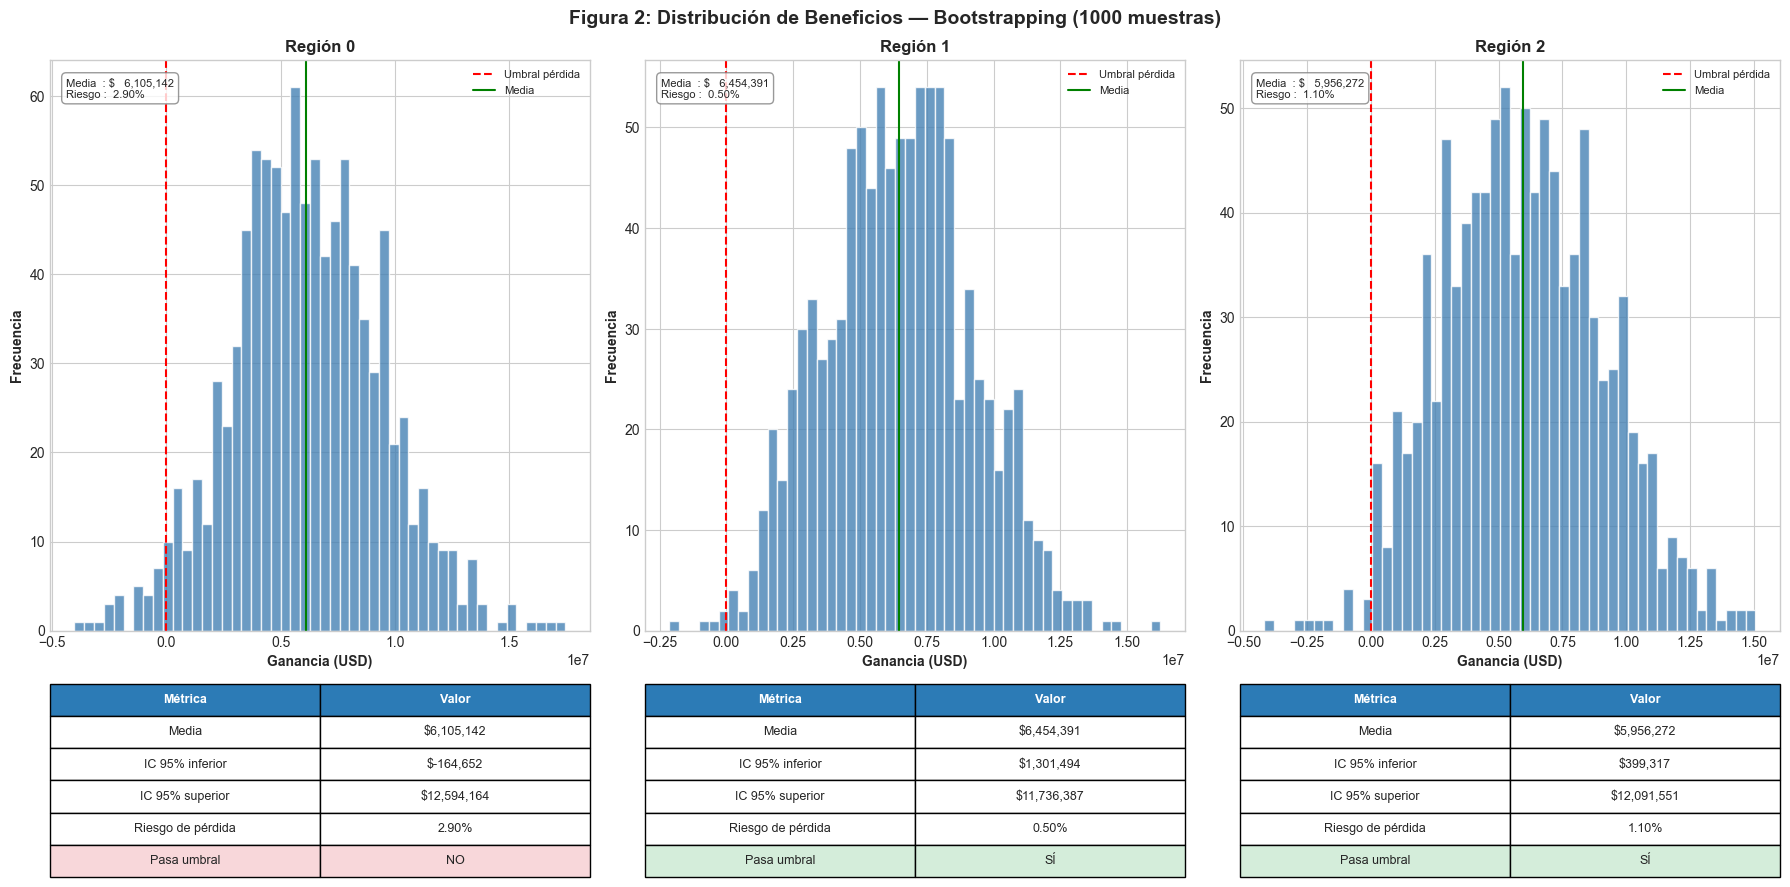

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9),
                         gridspec_kw={'height_ratios': [3, 1]})                                            # fila 1 más alta que fila 2

# ----------------- Fila 1: histogramas ---------------------------------------------------------------
for ax, boot, res in zip(axes[0], [boot_0, boot_1, boot_2], [res_0, res_1, res_2]):                       # Itera sobre cada subgráficas, sus datos de bootstrapping y su resumen
    ax.hist(boot, bins=50, color='steelblue', edgecolor='white', alpha=0.8)                               # Dibuja el histograma con 50 barras
    ax.axvline(0,            color='red',   linestyle='--', linewidth=1.5, label='Umbral pérdida')        # Traza línea vertical en 0, para marcar umbral de pérdida
    ax.axvline(res['media'], color='green', linestyle='-',  linewidth=1.5, label='Media')                 # Traza línea vertical en el beneficio promedio

    texto = (                                                                                             # Leyenda lado izquierdo
        f"Media  : ${res['media']:>12,.0f}\n"
        f"Riesgo :  {res['riesgo']*100:.2f}%"
    )
    ax.text(0.03, 0.97, texto,
            transform           = ax.transAxes,
            fontsize            = 8,
            verticalalignment   = 'top',
            horizontalalignment = 'left',
            bbox = dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='gray'))

    ax.set_title(res['region'], fontweight='bold')
    ax.set_xlabel('Ganancia (USD)', fontweight='bold')
    ax.set_ylabel('Frecuencia',     fontweight='bold')
    ax.legend(fontsize=8)

# --------------------- Fila 2: tabla resumen ---------------------------------------------------------
for ax, res in zip(axes[1], [res_0, res_1, res_2]):
    ax.axis('off')                                                                                       # Itera y une: desactiva ejes para que solo se vea la tabla

    datos_tabla = [
        ['Métrica',          'Valor'],
        ['Media',            f"${res['media']:,.0f}"],
        ['IC 95% inferior',  f"${res['ic_low']:,.0f}"],
        ['IC 95% superior',  f"${res['ic_high']:,.0f}"],
        ['Riesgo de pérdida',f"{res['riesgo']*100:.2f}%"],
        ['Pasa umbral',      'SÍ' if res['riesgo'] < 0.025 else 'NO'],
    ]

    tabla = ax.table(cellText    = datos_tabla[1:],                                                       # Filas de datos
                     colLabels   = datos_tabla[0],                                                        # Encabezados
                     loc         = 'center',
                     cellLoc     = 'center')

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(9)
    tabla.scale(1, 1.6)                                                                                   # Escala altura de filas

    # Color de encabezado
    for col in range(2):
        tabla[0, col].set_facecolor('#2c7bb6')
        tabla[0, col].set_text_props(color='white', fontweight='bold')

    # Color condicional en fila 'Pasa umbral' (fila índice 5)
    color_umbral = '#d4edda' if res['riesgo'] < 0.025 else '#f8d7da'                                      # verde o rojo suave
    for col in range(2):
        tabla[5, col].set_facecolor(color_umbral)

plt.suptitle('Figura 2: Distribución de Beneficios — Bootstrapping (1000 muestras)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **OBSERVACIONES - ANÁLISIS DE RIESGOS CON BOOTSTRAPPING**

**RIESGO DE PÉRDIDA**

| Región | Beneficio Promedio (USD) | IC 95% Inferior (USD)  | IC 95% Superior (USD)  | Riesgo de Pérdida (%) | Cumple criterio <2.5% |
|------------------|---------------|-------------------------|-------------------------|-----------------------|------------------------|
| Región 0         | 6,105,142     |  -164,652               |     12,594,164          |       2.90%           |            ❌          |
| Región 1         | 6,454,391     | 1,301,494               |     11,736,387          |       0.50%           |            ✅          |
| Región 2         | 5,956,272     |  399,317                |     12,091,551          |      1.10%            |            ✅          |
 
**Beneficio Promedio** 

* Las tres regiones son muy similares en ganancia esperada, rondando los ```$ 6 millones USD``` tras simular 1000 escenarios de selección de pozos. No existe alguna diferencia dramática entre ellas en este indicador, por lo tanto el beneficio promedio por sí solo no es un criterio suficiente para elegir entre regiones.

**Intervalo de confianza 95%** 

* La Región 0 toca territorio negativo en su límite inferior ```($-164,652)```, lo que indica que en el peor de los escenarios simulados (2.5%), la inversión no se recupera y el proyecto genera pérdidas.

* Las `Regiones 1 y 2` tienen su límite inferior positivo, lo que indica que en escenarios desfavorecidos se recupera la inversión.

**Riesgo de Pérdida**

Este es el criterio final del proyecto, con un umbral máximo permitido del 2.5%:

* **Región 0: 2.90%** Queda descartado por superar el límite permitido.

* **Región 2: 1.10%** Representa una opción viable, ya que cumple el criterio aunque con menor margen de seguridad.

* **Región 1: 0.50%** Casi 6 veces por debajo del umbral establecido, es el riesgo más bajo de las tres regiones, siendo `REGIÓN 1` la recomendación más solida para la inversión.


---
# <span style='color:#1B3A6B;'> 9. CONCLUSIONES </span>
---
## <span style='color:#2E86AB;'> 9.1. Región Recomendad y Justificación </span>

**Región Recomendada: Región 1**

Tras completar el pipeline completo de análisis, exploración de datos (EDA), entrenamiento del modelo (Regresión Lineal), con una selección de 200 pozos y validación estadística mediante **Bootstrapping** con 1000 muestras; la `REGIÓN 1` emerge como la opción **más sólida y confiable** de las tres evaluadas.

Vale destacar que la Región 1 durante el EDA mostró el menor volumen medio de reservas y ninguna de las tres regiones superó el umbral, demostrando que la precisión del modelo **importa más** que el promedio general de la región, por que determina la calidad de la selección de pozos sobre la que se calcula la ganancia real.

**Argumentos que Sustentan la Recomendación**

1. **Mayor beneficio promedio ($6,454,391 USD)** de las tres regiones, aunque la diferencia absoluta entre regiones es moderada de apenas 498,119 USD separan la región más rentable de la menos rentable, confirmando que este criterio no es suficiente; por lo tanto, debe analizarse en conjunto con el riesgo.

2. **Menor riesgo de pérdida (0.50%)** el más alejado del umbral 2.5%; se convierte en el argumento más contundente, con un riesgo de pérdida casi 6 veces por debajo del umbral permitido. La Región 1 es la única que ofrece una garantía estadística robusta de rentabilidad. Las 1000 simulaciones de bootstrapping respaldan que este resultado no es producto del azar, sino de una estructura de datos favorables para el modelo.

3. **Intervalo de confianza inferior más alto ($1,301,494 USD)** indica una mayor seguridad,  incluso en escenarios adversos la Región 1 genera ganancias positivas. Este indicador es conservador y relevante, garantiza que la inversión se recupera incluso bajo condiciones desfavorables, algo que las otras dos regiones no pueden asegurar con la misma solidez.

4. **Consistencia a lo largo de todo el análisis** El modelo de regresión lineal para la **Región 1** obtuvo un `RMSE CV de 0.89`, con una `desviación estándar de 0.00` y un `error relativo de apenas 1.30% del volumen medio predicho`, considerablemente menor que las Regiones 0 y 2, cuyos RMSE superan los 37 puntos (40.79% y 42.27% respectivamente). La validación cruzada con 5 folds confirma que este resultado no fue producto de una partición afortunada; en cada fold el modelo obtiene exactamente el mismo error, lo que prueba que la relación entre f2 y product es un patrón real y estable que el modelo captura sin depender de qué datos le toquen. Esto hace que las predicciones sobre las que se basa la selección de los 200 mejores pozos sean significativamente más precisas, reduciendo la incertidumbre en la selección y haciendo más confiable el resultado final del bootstrapping.  

5. **El gráfico 1 de dispersión de predicciones vs valores reales** refuerza visualmente la superioridad del modelo de la **Región 1**, mientras las Regiones 0 y 2 muestran nubes de puntos dispersas que evidencian alta incertidumbre en predicciones individuales, la Región 1 presenta puntos agrupados en bandas casi perfectamente alineadas sobre la diagonal, confirmando que la regresión lineal capturó una estructura discreta y predecible que las otras regiones no poseen.

---

**Posición de las otras regiones:**

La **Región 2** también aprueba el criterio de riesgo con un 1.10%, sería una segunda opción válida, pero su intervalo de confianza inferior (IC $399,317 USD) es más ajustado al umbral de 0 y su beneficio promedio es el más bajo de las tres regiones.


La **Región 0** queda descartada, a pesar de tener un beneficio promedio razonable ($6,105,142), el riesgo de pérdida es de 2.90% superando el límite permitido (2.5%), además su IC inferior toca territorio negativo (-164,652 USD), lo que implica que en escenarios más adversos la inversión no se recupera.



## <span style='color:#2E86AB;'> 9.2. Coincide con la Elección Preliminar del Paso 7 ? </span>


1. No coincide completamente. La elección preliminar (paso 7) identificó a la Región 0 como la más rentable con `$33,591,411 USD`, superando a la Región 1 `$24,150,867 USD`. Sin embargo, ese análisis calculaba la ganancia sobre una única muestra fija sin considerar **incertidumbre estadística**, por lo que no era suficiente para una decisión de inversión de $100 millones USD.

2. El bootstrapping revela que la ventaja preliminar de la Región 0 era frágil: su riesgo de pérdida (2.90%) supera el umbral permitido del 2.5% y su intervalo de confianza toca territorio negativo (-$164,652), lo que significa que bajo escenarios adversos la inversión no se recupera.

3. La Región 1 se consolida como la elección final por la precisión de su modelo (RMSE de 0.89). Esa precisión se explica por el comportamiento casi discreto de f2, que la regresión lineal capturó perfectamente, lo que produjo selecciones de pozos consistentes y estables a lo largo de las 1,000 simulaciones del **bootstrapping**, traduciéndose en el menor riesgo de pérdida (0.50%) y el intervalo de confianza inferior más alto ($1,301,494 USD).
